In [59]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [101]:
df = pd.read_csv('data/V-Dem-CY-Core-v15.csv')
print(df.shape)


(27913, 1818)


In [102]:
years_to_keep = [2000, 2005, 2010, 2015, 2020, 2023]

# Filter dataframe to keep only selected years
df_filtered = df[df['year'].isin(years_to_keep)].reset_index(drop=True)
print(df_filtered.shape)

(1069, 1818)


In [103]:
columns_to_keep = ['country_name', 'country_text_id', 'country_id', 'year', 
                   'v2x_polyarchy', 'v2x_api', 'v2x_mpi', 'v2x_frassoc_thick',
                   'v2x_suffr', 'v2xel_frefair', 'v2x_elecoff',
                   'v2x_libdem', 'v2x_polyarchy', 'v2x_liberal', 'v2xcl_rol',
                   'v2x_jucon', 'v2xlg_legcon', 
                   'v2x_partipdem', 'v2x_polyarchy', 'v2x_partip', 'v2x_cspart',
                   'v2xdd_dd', 'v2xel_locelec', 'v2xel_regelec', 
                   'v2x_delibdem', 'v2x_polyarchy', 'v2xdl_delib', 
                   'v2x_egaldem', 'v2x_polyarchy', 'v2x_egal', 'v2xeg_eqprotec',
                   'v2xeg_eqaccess', 'v2xeg_eqdr', 
                   'v2x_regime', 'v2x_elecreg', 'v2xex_elecreg', 
                   'v2x_polyarchy', 'v2x_liberal', 'v2x_accountability',
                   'v2x_diagacc', 'v2x_horacc', 'v2x_ex_confidence', 'v2x_ex_direlect',
                   'v2x_ex_hereditary', 'v2x_ex_military', 'v2x_ex_party', 'v2x_neopat',
                   'v2xnp_client', 'v2xnp_pres', 'v2xnp_regcorr', 'v2x_civlib', 'v2x_clphy',
                   'v2x_clpol', 'v2x_clpriv', 'v2xpe_exlecon', 'v2xpe_exlgender', 'v2xpe_exlgeo',
                   'v2xpe_exlpol', 'v2xpe_exlsocgr', 'v2x_corr', 'v2x_execorr', 'v2x_pubcorr',
                   'v2x_gender', 'v2x_gencl', 'v2x_gencs', 'v2x_genpp', 'v2x_rule', 'v2xdd_cic',
                   'v2xdd_i_ci', 'v2xdd_i_rf', 'v2xdd_toc', 'v2xdd_i_pl', 'v2xdd_i_or', 'v2xcs_ccsi',
                   'v2x_elecreg', 'v2xel_elecparl', 'v2xlg_leginter', 'v2xel_elecpres', 'v2x_hosinter',
                   'v2x_hosabort', 'v2x_legabort', 'v2xex_elecreg', 'v2xel_elecpres', 'v2x_hosinter', 'v2x_hosabort',
                   'v2xlg_elecreg', 'v2xel_elecparl', 'v2xlg_leginter', 'v2x_legabort', 'v2x_EDcomp_thick',
                   'v2x_frassoc_thick', 'v2xex_elecleg', 'v2x_freexp', 'v2xme_altinf', 'v2xcl_disc',
                   'v2xcl_acjst', 'v2xcl_prpty', 'v2xcl_slave', 'v2xcl_slave', 'v2xps_party',
                   'v2x_feduni', 'v2xca_academ']

df = df_filtered[columns_to_keep]
print(df.shape)
df.head()

(1069, 102)


,country_name,country_text_id,country_id,year,v2x_polyarchy,v2x_api,v2x_mpi,v2x_frassoc_thick,v2x_suffr,v2xel_frefair,...,v2x_freexp,v2xme_altinf,v2xcl_disc,v2xcl_acjst,v2xcl_prpty,v2xcl_slave,v2xcl_slave,v2xps_party,v2x_feduni,v2xca_academ
0,Mexico,MEX,3,2000,0.664,0.842,0.486,0.797,1.0,0.814,...,0.801,0.707,0.790,0.392,0.746,0.563,0.563,0.931,0.993,0.891
1,Mexico,MEX,3,2005,0.710,0.867,0.553,0.821,1.0,0.876,...,0.801,0.777,0.790,0.392,0.746,0.563,0.563,0.931,0.993,0.928
2,Mexico,MEX,3,2010,0.661,0.839,0.481,0.816,1.0,0.772,...,0.756,0.815,0.745,0.392,0.746,0.544,0.544,0.924,0.993,0.924
3,Mexico,MEX,3,2015,0.639,0.827,0.451,0.793,1.0,0.737,...,0.754,0.829,0.785,0.400,0.746,0.589,0.589,0.915,0.963,0.922
4,Mexico,MEX,3,2020,0.663,0.841,0.485,0.812,1.0,0.809,...,0.713,0.801,0.803,0.339,0.825,0.608,0.608,0.877,0.990,0.858


In [104]:
# Drop rows with na, it affects ~7.6% which is acceptable
df_clean = df.dropna()
print("Records dropped: ", df.shape[0] - df_clean.shape[0])




Records dropped:  78


In [105]:
# Remove identifiers from the features
identifiers = df_clean[['country_name', 'country_text_id', 'country_id', 'year']]

# Keep only the features for similarity analysis
features = df_clean.drop(columns=['country_name', 'country_text_id', 'country_id', 'year'])

print(features.shape)


(991, 98)


In [106]:
# Find the columns that need normaliztion

# Compute range and standard deviation for each feature
desc = features.describe().T
desc['range'] = desc['max'] - desc['min']

# Define a threshold for "suspiciously large" range or std (tweakable)
range_threshold = desc['range'].median() * 2
std_threshold = desc['std'].median() * 2

# Flag columns that exceed either threshold
needs_normalization = desc[(desc['range'] > range_threshold) | (desc['std'] > std_threshold)]

print("Columns that likely need normalization or scaling:")
print(needs_normalization[['mean', 'std', 'min', 'max', 'range']])


Columns that likely need normalization or scaling:
                        mean       std    min    max  range
v2x_regime          1.650858  0.972966  0.000  3.000  3.000
v2x_accountability  0.672859  0.859107 -1.690  2.054  3.744
v2x_diagacc         0.690948  0.871432 -2.116  2.066  4.182
v2x_horacc          0.449688  0.955414 -2.028  2.331  4.359
v2xdd_i_pl          0.490299  0.648376  0.000  2.000  2.000
v2xdd_i_or          0.290947  0.486155  0.000  2.000  2.000


In [ ]:
# Normalize the features using MinMaxScaler

columns_to_scale = ['v2x_regime', 'v2x_accountability', 'v2x_diagacc', 
                    'v2x_horacc', 'v2xdd_i_pl', 'v2xdd_i_or']

# Make a copy to avoid overwriting
features_normalized = features.copy()

# Apply MinMaxScaler to only those columns
scaler = MinMaxScaler()
features_normalized[columns_to_scale] = scaler.fit_transform(features[columns_to_scale])



In [108]:
# Check if all columns look good after scaling

# Compute range and standard deviation for each feature
desc = features_normalized.describe().T
desc['range'] = desc['max'] - desc['min']

# Define a threshold for "suspiciously large" range or std (tweakable)
range_threshold = desc['range'].median() * 2
std_threshold = desc['std'].median() * 2

# Flag columns that exceed either threshold
needs_normalization = desc[(desc['range'] > range_threshold) | (desc['std'] > std_threshold)]

print("Columns that likely need normalization or scaling:")
print(needs_normalization[['mean', 'std', 'min', 'max', 'range']])

Columns that likely need normalization or scaling:
Empty DataFrame
Columns: [mean, std, min, max, range]
Index: []


In [109]:


def find_similar_countries(query_country, query_year, features_df, identifiers_df, metric="cosine", top_n=10):
    # Step 1: Find index of the query
    query_mask = (identifiers_df['country_name'] == query_country) & (identifiers_df['year'] == query_year)
    if not query_mask.any():
        raise ValueError(f"No entry found for {query_country} in {query_year}")
    
    query_index = identifiers_df[query_mask].index[0]

    # Step 2: Extract feature vector of query country
    query_vector = features_df.iloc[query_index].values.reshape(1, -1)

    # Step 3: Compute similarity/distance
    if metric == "cosine":
        sims = cosine_similarity(query_vector, features_df)[0]
        scores = list(enumerate(sims))
        # Sort by descending similarity
        sorted_scores = sorted(scores, key=lambda x: -x[1])
    elif metric == "euclidean":
        dists = euclidean_distances(query_vector, features_df)[0]
        scores = list(enumerate(dists))
        # Sort by ascending distance
        sorted_scores = sorted(scores, key=lambda x: x[1])
    else:
        raise ValueError("Metric must be 'cosine' or 'euclidean'")

    # Step 4: Exclude the query country itself
    sorted_scores = [s for s in sorted_scores if s[0] != query_index]

    # Step 5: Get top N
    top_indices = [i for i, _ in sorted_scores[:top_n]]

    # Step 6: Return with identifiers and similarity/distance scores
    result = identifiers_df.iloc[top_indices].copy()
    result['score'] = [sorted_scores[i][1] for i in range(top_n)]

    return result


In [152]:
top_similar = find_similar_countries(
    query_country='Ukraine',
    query_year=2005,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='cosine',
    top_n=10
)
print("Top similar countries to Ukraine in 2005:")
print(top_similar)


Top similar countries to Ukraine in 2005:
    country_name country_text_id  country_id  year     score
599      Belarus             BLR         107  2010  0.961250
681   Kazakhstan             KAZ         121  2000  0.959968
600      Belarus             BLR         107  2015  0.959166
576      Algeria             DZA         103  2015  0.957749
597      Belarus             BLR         107  2000  0.955565
683   Kazakhstan             KAZ         121  2010  0.955529
575      Algeria             DZA         103  2010  0.947923
577      Algeria             DZA         103  2020  0.947066
685   Kazakhstan             KAZ         121  2020  0.947012
574      Algeria             DZA         103  2005  0.943293


In [153]:
top_similar = find_similar_countries(
    query_country='Ukraine',
    query_year=2010,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='cosine',
    top_n=10
)

print("Top similar countries to Ukraine in 2010:")
print(top_similar)

Top similar countries to Ukraine in 2010:
    country_name country_text_id  country_id  year     score
600      Belarus             BLR         107  2015  0.997846
601      Belarus             BLR         107  2020  0.966365
682   Kazakhstan             KAZ         121  2005  0.961889
598      Belarus             BLR         107  2005  0.961250
684   Kazakhstan             KAZ         121  2015  0.953035
792   Uzbekistan             UZB         140  2023  0.932485
663      Georgia             GEO         118  2000  0.923943
48        Russia             RUS          11  2000  0.921797
681   Kazakhstan             KAZ         121  2000  0.921342
683   Kazakhstan             KAZ         121  2010  0.920201


In [154]:
top_similar = find_similar_countries(
    query_country='Ukraine',
    query_year=2015,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='cosine',
    top_n=10
)
print("Top similar countries to Ukraine in 2015:")
print(top_similar)

Top similar countries to Ukraine in 2015:
    country_name country_text_id  country_id  year     score
599      Belarus             BLR         107  2010  0.997846
601      Belarus             BLR         107  2020  0.967509
682   Kazakhstan             KAZ         121  2005  0.961575
598      Belarus             BLR         107  2005  0.959166
684   Kazakhstan             KAZ         121  2015  0.957774
663      Georgia             GEO         118  2000  0.935429
760         Togo             TGO         134  2005  0.928144
792   Uzbekistan             UZB         140  2023  0.927687
48        Russia             RUS          11  2000  0.926731
576      Algeria             DZA         103  2015  0.924978


In [155]:
top_similar = find_similar_countries(
    query_country='Ukraine',
    query_year=2023,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='cosine',
    top_n=10
)
print("Top similar countries to Ukraine in 2023:")
print(top_similar)

Top similar countries to Ukraine in 2023:
    country_name country_text_id  country_id  year     score
601      Belarus             BLR         107  2020  0.934652
598      Belarus             BLR         107  2005  0.931823
543      Tunisia             TUN          98  2000  0.922416
553      Türkiye             TUR          99  2020  0.920950
578      Algeria             DZA         103  2023  0.915398
545      Tunisia             TUN          98  2010  0.913798
544      Tunisia             TUN          98  2005  0.908663
683   Kazakhstan             KAZ         121  2010  0.906039
577      Algeria             DZA         103  2020  0.905265
685   Kazakhstan             KAZ         121  2020  0.905020


In [156]:
top_similar = find_similar_countries(
    query_country='China',
    query_year=2023,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='euclidean',
    top_n=10
)

print("Top similar countries to China in 2023 (Euclidean):")
print(top_similar)

Top similar countries to China in 2023 (Euclidean):
      country_name country_text_id  country_id  year     score
669  Guinea-Bissau             GNB         119  2000  0.550857
671  Guinea-Bissau             GNB         119  2010  1.423071
672  Guinea-Bissau             GNB         119  2015  1.529529
673  Guinea-Bissau             GNB         119  2020  1.613580
710     Madagascar             MDG         125  2023  1.645297
761           Togo             TGO         134  2010  1.656264
663        Georgia             GEO         118  2000  1.708774
760           Togo             TGO         134  2005  1.742332
109     Bangladesh             BGD          24  2005  1.874939
652          Gabon             GAB         116  2005  1.913919


In [157]:
top_similar = find_similar_countries(
    query_country='Finland',
    query_year=2023,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='cosine',
    top_n=10
)
print("Top similar countries to Finland in 2023:")
print(top_similar)

Top similar countries to Finland in 2023:
     country_name country_text_id  country_id  year     score
952         Malta             MLT         178  2015  0.997156
954         Malta             MLT         178  2023  0.995103
969   New Zealand             NZL         185  2010  0.988368
462        Latvia             LVA          84  2015  0.987969
970   New Zealand             NZL         185  2015  0.986631
967   New Zealand             NZL         185  2000  0.984542
463        Latvia             LVA          84  2020  0.982131
1058      Hungary             HUN         210  2005  0.981271
951         Malta             MLT         178  2010  0.976767
950         Malta             MLT         178  2005  0.976488


In [149]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_styled_similarity_table(result_df, title="Top Similar Countries"):
    """
    Plots a more visually appealing similarity table using the output of find_similar_countries().
    """

    df = result_df[['country_name', 'year', 'score']].copy()
    df.columns = ['Country', 'Year', 'Similarity Score']
    df['Similarity Score'] = df['Similarity Score'].round(3)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    # Create the table data
    cell_text = []
    for i, row in df.iterrows():
        cell_text.append([row['Country'], row['Year'], row['Similarity Score']])

    # Add alternating row colors
    row_colors = ['#f7f7f7' if i % 2 == 0 else '#ffffff' for i in range(len(df))]

    table = ax.table(
        cellText=cell_text,
        colLabels=df.columns,
        colColours=['#dddddd'] * 3,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)

    # Style headers
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='black')
            cell.set_facecolor('#cccccc')
        elif row > 0:
            cell.set_facecolor(row_colors[row - 1])

    plt.tight_layout()
    plt.show()



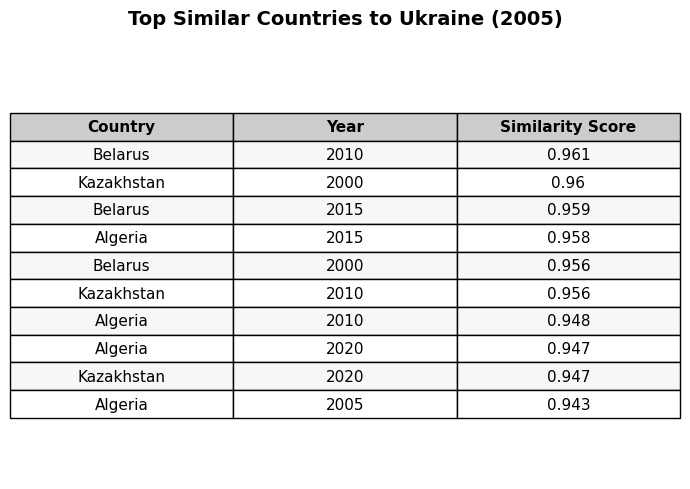

In [151]:
top_similar = find_similar_countries(
    query_country='Ukraine',
    query_year=2005,
    features_df=features_normalized,
    identifiers_df=identifiers,
    metric='cosine',
    top_n=10
)

plot_styled_similarity_table(top_similar, title="Top Similar Countries to Ukraine (2005)")
